In [64]:
import os
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


import sys
sys.path.append('../')
import sionna

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

sionna.config.seed = 42 # Set seed for reproducible random number generation

# Load the required Sionna components
from sionna.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver, CarrierConfig, PUSCHDMRSConfig,\
                        TBConfig, PUSCHPilotPattern, TBEncoder, PUSCHPrecoder, LayerMapper, LayerDemapper, check_pusch_configs,\
                        TBDecoder, PUSCHLSChannelEstimator
from sionna.nr.utils import generate_prng_seq
from sionna.channel import AWGN, RayleighBlockFading, OFDMChannel, TimeChannel, time_lag_discrete_time_channel
from sionna.channel.utils import *
from sionna.channel.tr38901 import Antenna, AntennaArray, UMi, UMa, RMa, TDL, CDL
from sionna.channel import gen_single_sector_topology as gen_topology
from sionna.utils import compute_ber, ebnodb2no, sim_ber, BinarySource
from sionna.ofdm import KBestDetector, LinearDetector, MaximumLikelihoodDetector,\
        LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers, ResourceGridDemapper,\
        ResourceGrid, ResourceGridMapper, OFDMModulator
from sionna.mimo import StreamManagement
from sionna.mapping import Mapper, Demapper

In [65]:
# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')
print('Number of GPUs available :', len(gpus))
if gpus:
    gpu_num = 0 # Index of the GPU to be used
    try:
        #tf.config.set_visible_devices([], 'GPU')
        tf.config.set_visible_devices(gpus[gpu_num], 'GPU')
        print('Only GPU number', gpu_num, 'used.')
        tf.config.experimental.set_memory_growth(gpus[gpu_num], True)
    except RuntimeError as e:
        print(e)

Number of GPUs available : 0


In [66]:
import re
import math

def config_parser(config_path):
    caseInfo = {}
    sysInfo = {}
    ue = {}
    chcfg = {}
    auxInfo = {}
    with open(config_path, 'r') as file:
        for num, line in enumerate(file, 1):
            line = line.strip()
            if line and not line.startswith('%'):  # Ignore empty or comment lines
                #read case information and store it in caseInfo
                key, value = line.split('=')
                key = key.strip()
                value = value.strip('; ').strip()
                if value.lower() == 'true': 
                    value = True
                elif value.lower() == 'false':
                    value = False
                elif value.isdigit():  # Convert to integer if the value is a number
                    value = int(value)
                if num < 3:
                    caseInfo[key] = value    
                else:
                    #read cell information  
                    if key.startswith('sys'):
                        _, value2 = key.split('.')
                        sysInfo[value2] = value
                    #read chcfg information
                    elif key.startswith('chcfg'): 
                        _, value2 = key.split('.')
                        chcfg[value2] = value
                    #read ue config
                    elif key.startswith('ue'): 
                        key2, value2 = key.split('.')
                        ue_idx = re.search(r"\{([^}]+)\}", key2)
                        ue_idx = ue_idx.group(1)
                        if ue_idx.isdigit():
                            ue_idx = int(ue_idx) 
                        if is_empty(ue, ue_idx) == 0 :
                            #create an empty config dictionary for ue_idx                     
                            ue[ue_idx] = {}
                        ue[ue_idx][value2] = value
                    else:
                        auxInfo[key] = value                
    return caseInfo, sysInfo, ue, chcfg, auxInfo    

def is_empty(dictionary, key):
    # Check if the key exists and if the value is considered "empty"
    if key in dictionary:
        return True
    return False

def fft_size_return(n):
    if n <= 1:
        return 1    
    if n >= 0.85*2**math.ceil(math.log2(n)):
        return 2**(math.ceil(math.log2(n))+1)
    else:
        return 2 ** math.ceil(math.log2(n))

In [67]:
from pathlib import Path
import struct
import numpy as np

# Path to the data file
field_dir = '../Pusch_data/data_field'
data_path = f'{field_dir}/dump_pass_sfn_6_sf_5_freq.bin'
cfg_path = f'{field_dir}/dump_pass_sfn_6_sf_5_cfg.txt'

freq = []

with open(data_path, 'rb') as file:
    binary_data = file.read()
    
    # Loop through the binary data in chunks of 2 bytes (since int16 is 2 bytes)
    for i in range(0, len(binary_data), 4):
        # Convert the chunk to an integer and append it to the list
        real = binary_data[i:i+2]
        imag = binary_data[i+2:i+4]

        #unpack the 2 bytes into a little-endian int16
        if len(real) == 2:
            real_part = struct.unpack('<h', real)[0]
            imag_part = struct.unpack('<h', imag)[0]
            freq.append(complex(real_part, imag_part))

freq = np.array(freq)
print(freq.shape)
# print("Unpacked int16 value:\n", freq)

# Load configuration parameters from the file .txt
caseInfo, sysInfo, ue, chcfg, auxInfo = config_parser(cfg_path)  

#reshape the iq data into resource grid (Numsubcarrier x 14 Sym x 8 ant)
freq = freq.reshape((sysInfo['BwpNRb']*12, 14, sysInfo['NRxAnt'], ))
print(freq.shape)
iqUe = freq[ue[1]['FirstPrb']*12:(ue[1]['NPrb'] + ue[1]['FirstPrb'] + 1)*12,:, :]
iqUe = iqUe[np.newaxis,:]
iqUe = iqUe.astype(np.complex64)

(217728,)
(1944, 14, 8)


In [68]:
iqUe.shape

(1, 1680, 14, 8)

In [69]:
sysInfo

{'NCellId': 246,
 'FrequencyRange': 1,
 'BandWidth': 60,
 'Numerology': 1,
 'CpType': 0,
 'NTxAnt': 1,
 'NRxAnt': 8,
 'BwpNRb': 162,
 'BwpRbOffset': 0,
 'harqProcFlag': 0,
 'nHarqProc': 1,
 'rvSeq': 0}

In [70]:
ue

{1: {'rvIdx': 0,
  'TransformPrecoding': 0,
  'Rnti': 20002,
  'nId': 246,
  'CodeBookBased': 0,
  'DmrsPortSetIdx': 1,
  'NLayers': 1,
  'NumDmrsCdmGroupsWithoutData': 2,
  'Tpmi': 0,
  'FirstSymb': 0,
  'NPuschSymbAll': 14,
  'RaType': 1,
  'FirstPrb': 22,
  'NPrb': 140,
  'FrequencyHoppingMode': 0,
  'McsTable': 0,
  'Mcs': 7,
  'ILbrm': 0,
  'nScId': 0,
  'NnScIdId': 246,
  'DmrsConfigurationType': 0,
  'DmrsDuration': 1,
  'DmrsAdditionalPosition': 2,
  'PuschMappingType': 0,
  'DmrsTypeAPosition': 3,
  'HoppingMode': 0,
  'NRsId': 0,
  'Ptrs': 0,
  'ScalingFactor': 0,
  'OAck': 0,
  'IHarqAckOffset': 11,
  'OCsi1': 0,
  'ICsi1Offset': 0,
  'OCsi2': 0,
  'ICsi2Offset': 0,
  'NPrbOh': 0,
  'nCw': 1,
  'TpPi2Bpsk': 0}}

In [71]:
class MyPUSCHConfig(PUSCHConfig):
    def __init__(self, sysInfo, ue, chcfg, auxInfo):
        super().__init__(
            carrier_config=CarrierConfig(
                n_cell_id=sysInfo['NCellId'],
                cyclic_prefix="normal",
                subcarrier_spacing=30,
                n_size_grid=sysInfo['BwpNRb'],
                n_start_grid=sysInfo['BwpRbOffset'],
                slot_number=caseInfo['sf'],
                frame_number=caseInfo['sfn']
            ),
            pusch_dmrs_config=PUSCHDMRSConfig(
                config_type=ue[1]['DmrsConfigurationType'] + 1,
                length=ue[1]['DmrsDuration'],
                additional_position=ue[1]['DmrsAdditionalPosition'],
                dmrs_port_set=[1],
                n_id=ue[1]['NnScIdId'],
                n_scid=ue[1]['nScId'],
                num_cdm_groups_without_data=2,
                type_a_position=ue[1]['DmrsTypeAPosition']
            ),
            tb_config=TBConfig(
                channel_type='PUSCH',
                n_id=ue[1]['nId'],
                mcs_table=ue[1]['McsTable'] + 1,
                mcs_index=ue[1]['Mcs']
            ),
            mapping_type='A',
            n_size_bwp=ue[1]['NPrb'],
            n_start_bwp=1, #ue[1]['FirstPrb'],
            num_layers=1,
            num_antenna_ports=1,
            precoding='non-codebook',
            tpmi=ue[1]['Tpmi'],
            transform_precoding=False,
            n_rnti=ue[1]['Rnti'],
            symbol_allocation=[0,14]
        )

MyPUSCHConfig(sysInfo, ue, chcfg, auxInfo).show()

Carrier Configuration
cyclic_prefix : normal
cyclic_prefix_length : 2.3437500000000002e-06
frame_duration : 0.01
frame_number : 6
kappa : 64.0
mu : 1
n_cell_id : 246
n_size_grid : 162
n_start_grid : 0
num_slots_per_frame : 20
num_slots_per_subframe : 2
num_symbols_per_slot : 14
slot_number : 5
sub_frame_duration : 0.001
subcarrier_spacing : 30
t_c : 5.086263020833334e-10
t_s : 3.2552083333333335e-08

PUSCH Configuration
dmrs_grid : shape (1, 1680, 14)
dmrs_grid_precoded : shape ()
dmrs_mask : shape (1680, 14)
dmrs_symbol_indices : [3, 7, 11]
frequency_hopping : neither
l : [3, 7, 11]
l_0 : 3
l_bar : [3, 7, 11]
l_d : 14
l_prime : [0]
l_ref : 0
mapping_type : A
n : shape (420,)
n_rnti : 20002
n_size_bwp : 140
n_start_bwp : 1
num_antenna_ports : 1
num_coded_bits : 36960
num_layers : 1
num_ov : 0
num_res_per_prb : 132
num_resource_blocks : 140
num_subcarriers : 1680
precoding : non-codebook
precoding_matrix : None
symbol_allocation : [0, 14]
tb_size : 18960
tpmi : 0
transform_precoding : F

In [72]:
_pusch_config = MyPUSCHConfig(sysInfo, ue, chcfg, auxInfo)

_n_size_grid = _pusch_config.carrier.n_size_grid
_n_start_grid = _pusch_config.carrier.n_start_grid

_tb_size = _pusch_config.tb_size
_num_coded_bits = _pusch_config.num_coded_bits
_target_coderate = _pusch_config.tb.target_coderate
_num_bits_per_symbol = _pusch_config.tb.num_bits_per_symbol
_num_layers = _pusch_config.num_layers
_n_rnti = _pusch_config.n_rnti
_n_id = _pusch_config.tb.n_id

_n_size_bwp = _pusch_config.n_size_bwp
_n_start_bwp = _pusch_config.n_start_bwp

_binary_source = BinarySource(dtype=tf.float32)

_tb_encoder = TBEncoder(
                target_tb_size=_tb_size,
                num_coded_bits=_num_coded_bits,
                target_coderate=_target_coderate,
                num_bits_per_symbol=_num_bits_per_symbol,
                num_layers=_num_layers,
                n_rnti=_n_rnti,
                n_id=_n_id,
                channel_type="PUSCH", # PUSCHTransmitter
                codeword_index=0, # not supported for PUSCH
                use_scrambler=True,
                verbose=False,
                output_dtype=tf.float32)

_mapper = Mapper("qam", _num_bits_per_symbol, dtype=tf.complex64)

_layer_mapper = LayerMapper(num_layers=_num_layers, dtype=tf.complex64)

_dmrs_length = _pusch_config.dmrs.length
_dmrs_additional_position = _pusch_config.dmrs.additional_position
_num_cdm_groups_without_data = _pusch_config.dmrs.num_cdm_groups_without_data
_n_scid = _pusch_config.dmrs.n_scid
_n_id_n_scid = _pusch_config.dmrs.n_id[0]

_pilot_pattern = PUSCHPilotPattern([_pusch_config],
                                        dtype=tf.complex64)
_mu = 1
_num_ofdm_symbols = 14
_fft_size = 2**(math.log2((_n_start_grid + _n_size_grid)*12).__ceil__())# 4096
print(_fft_size)
_cyclic_prefix_length = 288
_subcarrier_spacing = 30e3
_num_guard_subcarriers = (52+_n_start_bwp*12, _fft_size-(_n_start_bwp+_n_size_bwp)*12-52)
_num_slots_per_frame = 20

# Define the resource grid.
_resource_grid = ResourceGrid(
    num_ofdm_symbols=_num_ofdm_symbols,
    fft_size=_fft_size,
    subcarrier_spacing=_subcarrier_spacing,
    num_tx=1,
    num_streams_per_tx=1,
    cyclic_prefix_length=_cyclic_prefix_length,
    num_guard_carriers=_num_guard_subcarriers,
    dc_null=False,
    pilot_pattern=_pilot_pattern,
    dtype=tf.complex64
)

_resource_grid_mapper = ResourceGridMapper(_resource_grid, dtype=tf.complex64)

_num_tx = 1
_num_rx = 1
_num_tx_ant = 1
_num_rx_ant = 8
_carrier_frequency = 2.55e9  # Carrier frequency in Hz.
_link_direction = "uplink"
_rx_tx_association = np.ones([_num_rx, _num_tx], bool)
_stream_management = StreamManagement(_rx_tx_association, _num_layers)


# if 'neural-receiver' == decoding_scenario:
#     _model = _model
# elif 'openvino-model' == decoding_scenario:
#     ov_model = _compiled_model
# else:
#     if 'ls-without-prior' == decoding_scenario:
_channel_estimator = PUSCHLSChannelEstimator(
                _resource_grid,
                _dmrs_length,
                _dmrs_additional_position,
                _num_cdm_groups_without_data,
                interpolation_type='lin',
                dtype=tf.complex64)

_mimo_detector = LinearDetector("lmmse", "bit", "maxlog", _resource_grid,
                            _stream_management, "qam", _num_bits_per_symbol, dtype=tf.complex64)


_layer_demapper = LayerDemapper(_layer_mapper, num_bits_per_symbol=_num_bits_per_symbol)
_tb_decoder = TBDecoder(_tb_encoder, output_dtype=tf.float32)


2048


In [73]:
print(_fft_size,_num_guard_subcarriers)

2048 (64, 304)


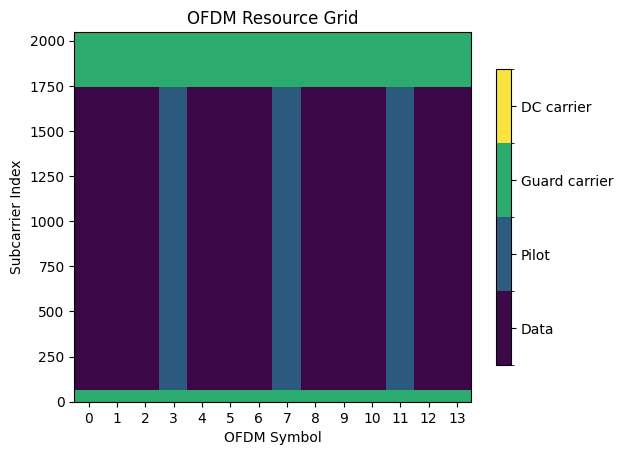

In [74]:
_resource_grid.show();

In [75]:
# Configure antenna arrays
ml = 'C'
spd = 1
ds = 150
_ue_antenna = Antenna(polarization="single",
                polarization_type="V",
                antenna_pattern="38.901",
                carrier_frequency=_carrier_frequency)

_gnb_array = AntennaArray(num_rows=1,
                        num_cols=_num_rx_ant//2,
                        polarization="dual",
                        polarization_type="cross",
                        antenna_pattern="38.901",
                        carrier_frequency=_carrier_frequency)

_channel_model = CDL(model = ml,
                            delay_spread = ds*1e-9,
                            carrier_frequency = _carrier_frequency,
                            ut_array = _ue_antenna,
                            bs_array = _gnb_array,
                            direction = _link_direction,
                            min_speed = spd,
                            max_speed = spd)

_channel = OFDMChannel(
                    _channel_model,
                    _resource_grid,
                    # normalize_channel=True,
                    return_channel=True)

In [76]:
b = _binary_source([1, _num_tx, _tb_size])
c = _tb_encoder(b)
x_map = _mapper(c)
x_layer = _layer_mapper(x_map)
x = _resource_grid_mapper(x_layer)

ebno_db = 1e100
no = ebnodb2no(ebno_db,
                _num_bits_per_symbol,
                _target_coderate,
                _resource_grid)
y, h = _channel([x, no])
y

<tf.Tensor: shape=(1, 1, 8, 14, 2048), dtype=complex64, numpy=
array([[[[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          ...,
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

         [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          ...,
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

         [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.

In [77]:
tf.math.reduce_max(tf.math.real(y[0,0]), [2, 1]),\
tf.math.reduce_min(tf.math.real(y[0,0]), [2, 1]),\
tf.math.reduce_max(tf.math.imag(y[0,0]), [2, 1]),\
tf.math.reduce_min(tf.math.imag(y[0,0]), [2, 1])

(<tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([6.789637 , 7.238257 , 7.061384 , 7.4738693, 4.023142 , 4.5286245,
        5.226714 , 5.6230164], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([-6.7823124, -7.2359776, -7.06886  , -7.4684734, -4.0281253,
        -4.527728 , -5.233461 , -5.62484  ], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([6.786622 , 7.234995 , 7.0715866, 7.471178 , 4.0300503, 4.5248537,
        5.237191 , 5.6231737], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([-6.7852516, -7.2405233, -7.0743   , -7.4710617, -4.0214477,
        -4.5301027, -5.2353306, -5.6215878], dtype=float32)>)

In [78]:
ueRxSigFreq = tf.transpose(iqUe[0], perm=[2,1,0])
tf.math.reduce_max(tf.math.real(ueRxSigFreq), [2, 1]),\
tf.math.reduce_min(tf.math.real(ueRxSigFreq), [2, 1]),\
tf.math.reduce_max(tf.math.imag(ueRxSigFreq), [2, 1]),\
tf.math.reduce_min(tf.math.imag(ueRxSigFreq), [2, 1])

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([169., 159., 158., 154., 169., 180., 173., 158.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([-153., -149., -154., -173., -130., -158., -166., -243.],
       dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([122., 150., 221., 160., 164., 194., 158., 237.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=
 array([-141., -215., -164., -183., -143., -104., -186., -170.],
       dtype=float32)>)

In [79]:
rxSigFreq = tf.Variable(tf.zeros_like(y))
rxSigFreq[...,_num_guard_subcarriers[0]:-_num_guard_subcarriers[1]].assign(ueRxSigFreq)

<tf.Variable 'UnreadVariable' shape=(1, 1, 8, 14, 2048) dtype=complex64, numpy=
array([[[[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          ...,
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

         [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          ...,
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],

         [[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0

In [91]:
no_arg = 0.001
h_hat,err_var = _channel_estimator([rxSigFreq, no_arg])
llr_det = _mimo_detector([rxSigFreq, h_hat, err_var, no_arg])
llr_layer = _layer_demapper(llr_det)
b_hat, tb_crc_status = _tb_decoder(llr_layer)
tb_crc_status

<tf.Tensor: shape=(1, 1), dtype=bool, numpy=array([[ True]])>

In [81]:
c_rec = _tb_encoder(b_hat)
x_map = _mapper(c)
x_layer = _layer_mapper(x_map)
x = _resource_grid_mapper(x_layer)
tf.math.reduce_sum(x, [0,1,2,-1])

<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([ 53.740105 +11.313704j ,  12.727923 +25.455841j ,
       -26.870056 -55.154324j , -14.       +20.j       ,
       -21.213202  -7.071065j ,   4.2426395-21.213205j ,
       -43.840614  -4.242634j ,   4.       -14.j       ,
        25.455841 +16.97056j  ,  -2.8284216 -1.4142122j,
        36.769547  +5.6568537j, -24.       +58.j       ,
        25.45584   -2.8284216j,  31.112694 +45.25483j  ], dtype=complex64)>

In [ ]:
""""<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([-21.213202  -7.071066j,  14.142134 +29.698483j,
       -29.698483 +22.627415j, -14.       +20.j      ,
         9.899498 -25.455845j,  -5.6568546-29.698479j,
         8.485277 -12.727919j,   4.       -14.j      ,
         8.485279  +7.071067j, -42.4264   +41.012196j,
        21.2132   +42.4264j  , -24.       +58.j      ,
       -31.112696  -9.899496j, -12.727922 -21.2132j  ], dtype=complex64)>"""

In [ ]:
# class MyPUSCHConfig(PUSCHConfig):
#     def __init__(self, sysInfo, ue, chcfg, auxInfo):
#         super().__init__(
#             carrier_config=CarrierConfig(
#                 n_cell_id=sysInfo['NCellId'],
#                 cyclic_prefix="normal",
#                 subcarrier_spacing=30,
#                 n_size_grid=sysInfo['BwpNRb'],
#                 n_start_grid=sysInfo['BwpRbOffset'],
#                 slot_number=caseInfo['sf'],
#                 frame_number=caseInfo['sfn']
#             ),
#             pusch_dmrs_config=PUSCHDMRSConfig(
#                 config_type=ue[1]['DmrsConfigurationType'] + 1,
#                 length=ue[1]['DmrsDuration'],
#                 additional_position=ue[1]['DmrsAdditionalPosition'],
#                 dmrs_port_set=[1],
#                 n_id=ue[1]['NnScIdId'],
#                 n_scid=ue[1]['nScId'],
#                 num_cdm_groups_without_data=2,
#                 type_a_position=ue[1]['DmrsTypeAPosition']
#             ),
#             tb_config=TBConfig(
#                 channel_type='PUSCH',
#                 n_id=ue[1]['nId'],
#                 mcs_table=ue[1]['McsTable'] + 1,
#                 mcs_index=ue[1]['Mcs']
#             ),
#             mapping_type='A',
#             n_size_bwp=ue[1]['NPrb'],
#             n_start_bwp=ue[1]['FirstPrb'] ,
#             num_layers=1,
#             num_antenna_ports=1,
#             precoding='non-codebook',
#             tpmi=ue[1]['Tpmi'],
#             transform_precoding=False,
#             n_rnti=ue[1]['Rnti'],
#             symbol_allocation=[0,14]
#         )

# MyPUSCHConfig(sysInfo, ue, chcfg, auxInfo).show()

In [17]:
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, SeparableConv2D
from tensorflow.nn import relu
class ResidualBlock(tf.keras.Model):
    r"""
    This Keras layer implements a convolutional residual block made of two convolutional layers with ReLU activation, layer normalization, and a skip connection.
    The number of convolutional channels of the input must match the number of kernel of the convolutional layers ``num_conv_channel`` for the skip connection to work.

    Input
    ------
    : [batch size, num time samples, num subcarriers, num_conv_channel], tf.float
        Input of the layer

    Output
    -------
    : [batch size, num time samples, num subcarriers, num_conv_channel], tf.float
        Output of the layer
    """

    def build(self, input_shape):

        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = SeparableConv2D(filters= 64,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = SeparableConv2D(filters= 128,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

class CustomNeuralReceiver(tf.keras.Model):
    r"""
    Keras layer implementing a residual convolutional neural receiver.

    This neural receiver is fed with the post-DFT received samples, forming a resource grid of size num_of_symbols x fft_size, and computes LLRs on the transmitted coded bits.
    These LLRs can then be fed to an outer decoder to reconstruct the information bits.

    Input
    ------
    y_no: [batch size, num ofdm symbols, num subcarriers, 2*num rx antenna + 1], tf.float32
        Concatenated received samples and noise variance.
(
    y : [batch size, num rx antenna, num ofdm symbols, num subcarriers], tf.complex
        Received post-DFT samples.

    no : [batch size], tf.float32
        Noise variance. At training, a different noise variance value is sampled for each batch example.
)
    Output
    -------
    : [batch size, num ofdm symbols, num subcarriers, num_bits_per_symbol]
        LLRs on the transmitted bits.
    """

    def __init__(self, training = False):
        super(CustomNeuralReceiver, self).__init__()
        self._training = training

    def build(self, input_shape):

        # Input convolution
        self._input_conv = Conv2D(filters= 128,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None)
        # Residual blocks
        self._res_block_1 = ResidualBlock()
        self._res_block_2 = ResidualBlock()
        self._res_block_3 = ResidualBlock()
        self._res_block_4 = ResidualBlock()
        # Output conv
        self._output_conv = Conv2D(filters= 2,    # QPSK
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None)
        

    @tf.function(jit_compile=True)
    def call(self, inputs):
        # Input conv
        z = self._input_conv(inputs)
        # Residual blocks
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        # Output conv
        z = self._output_conv(z)
        # if self._training == False:
        #     z = tf.cast(z * (2**7), tf.int8)
        return z

In [33]:
import pickle
_model = CustomNeuralReceiver(training = False)
inputs = tf.zeros([1,3276,14,16])
_model(inputs)
_model.summary()

def load_weights(model, pretrained_weights_path):
    # Build Model with random input
    # Load weights
  with open(pretrained_weights_path, 'rb') as f:
    weights = pickle.load(f)
    model.set_weights(weights)
    print(f"Loaded pretrained weights from {pretrained_weights_path}")

#load_weights(_model, '/content/drive/MyDrive/Pusch_data/Model_weights/model_weight_FULL_RB_epoch_40.pkl')
load_weights(_model, '../model_weight_FULL_RB_epoch_40.pkl')


Model: "custom_neural_receiver_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           multiple                  18560     
                                                                 
 residual_block_4 (Residual  multiple                  17630080  
 Block)                                                          
                                                                 
 residual_block_5 (Residual  multiple                  17630080  
 Block)                                                          
                                                                 
 residual_block_6 (Residual  multiple                  17630080  
 Block)                                                          
                                                                 
 residual_block_7 (Residual  multiple                  17630080  
 Block)                                   

In [47]:
rxSigFreq.shape

TensorShape([1, 1, 8, 14, 2048])

In [48]:
# rxSigFreq_3276 = tf.Variable(tf.zeros([1,1,8,14,3276], dtype=tf.complex64))
# rxSigFreq_3276[...,:2048].assign(y)
rxSigFreq_3276 = tf.pad(y, [[0, 0], [0, 0], [0, 0], [0, 0], [0, 3276-2048]], "REFLECT")

In [35]:
def predict_with_model(y, batch_size, num_coded_bits):
    def prep_y(y):
        # c = tf.transpose(tf.reshape(c, [c.shape[0], 12,-1,2]), perm=[0,2,1,3])
        # y = y[...,410:-410]
        print(y.shape)
        y = y[...,:]
        # _num_guard_subcarriers[0]:-_num_guard_subcarriers[1]

        # Concat Real and Image of y
        y = tf.concat([tf.math.real(y), tf.math.imag(y)], axis=2)
        y = y[:,0]
        y = tf.transpose(y, perm=[0,3,2,1])
        return y

    # y.shape, c.shape
    y_prep = prep_y(y)
    pred = _model(y_prep)
    pred = pred[:,:2048]
    pred = pred[:,_num_guard_subcarriers[0]:-_num_guard_subcarriers[1]]
    print(pred.shape)
    dmrs_mask = tf.constant([0,0,0,1,0,0,0,1,0,0,0,1,0,0])
    # pred = tf.concat([pred[...,0:2,:], pred[...,3:7,:], pred[...,8:11,:], pred[...,12:14,:]],axis=-2)
    pred = tf.boolean_mask(pred, mask=(dmrs_mask==0), axis=-2)

    pred = tf.transpose(pred, perm=[0,2,1,3])
    c_pred = tf.reshape(pred, [batch_size,1,1,num_coded_bits])

    return c_pred

In [38]:
tf.math.reduce_sum(x[0,0], [2,0])

<tf.Tensor: shape=(14,), dtype=complex64, numpy=
array([ 36.769554 +26.870052j , -74.95331  +26.870056j ,
         7.0710673-32.52691j  , -84.        +4.j       ,
       -11.313709 +18.384773j , -12.7279215+32.52691j  ,
         8.485281  -1.4142151j,   8.       -26.j       ,
       -12.727921 -55.154327j ,  16.970568 +11.313705j ,
         5.6568527+33.94112j  , -12.        +8.j       ,
        -7.071068  +7.0710707j,   7.071068 +24.04163j  ], dtype=complex64)>

In [44]:
llr_det = predict_with_model(rxSigFreq_3276, 1, _num_coded_bits)
llr_layer = _layer_demapper(llr_det)
b_hat, tb_crc_status = _tb_decoder(llr_layer)
tb_crc_status

(1, 1, 8, 14, 3276)
(1, 1680, 14, 2)


<tf.Tensor: shape=(1, 1), dtype=bool, numpy=array([[False]])>

In [45]:
def loss_cal(pred, labels):
  bce = tf.nn.sigmoid_cross_entropy_with_logits(labels, pred)
  bce = tf.reduce_mean(bce)
  # rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
  # loss = -rate
  loss = bce
  return loss

loss_cal(llr_det[0], c_rec)

<tf.Tensor: shape=(), dtype=float32, numpy=4.8679633>